## Topic Modeling with LDA & Social Network Analysis (SNA)


In [1]:
import nltk
import gensim
from gensim import corpora, models
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import scipy.stats
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import networkx.algorithms.community as nx_comm
from gensim.models.coherencemodel import CoherenceModel

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

### Load Dataset
Jalankan cell di bawah ini untuk memuat data. Silakan sesuaikan path pembacaan CSV jika menggunakan Google Colab.


In [2]:
csv_path = 'datamotor.csv'
if not os.path.exists(csv_path):
    csv_path = '../resource/datamotor.csv'
if not os.path.exists(csv_path):
    csv_path = r'd:\Dev\Project AJS\resource\datamotor.csv'

df = pd.read_csv(csv_path)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   conversationId            4459 non-null   int64  
 1   createdAt                 4459 non-null   str    
 2   id                        4459 non-null   int64  
 3   inReplyToId               2309 non-null   float64
 4   inReplyToUserId           0 non-null      float64
 5   inReplyToUsername         0 non-null      float64
 6   isConversationControlled  4459 non-null   bool   
 7   isPinned                  4459 non-null   bool   
 8   isQuote                   36 non-null     object 
 9   isReply                   4459 non-null   bool   
 10  likeCount                 4459 non-null   int64  
 11  quoteCount                4459 non-null   int64  
 12  replyCount                4459 non-null   int64  
 13  reply_to_user_results     0 non-null      float64
 14  retweetCount       

### Text Preprocessing & Author Extraction
Membersihkan teks tweet untuk pemodelan topik serta mengekstrak nama pengguna (author) dari URL tweet.


In [8]:
# ── Stopwords ──────────────────────────────────────────────────────────────
# Diletakkan di sini agar stopwords dan preprocessing berada dalam satu konteks

stop_words = set(stopwords.words('indonesian'))

additional_stopwords = [
    # Domain-specific noise (terlalu dominan / tidak diskriminatif antar topik)
    'mbg', 'motor', 'listrik', 'https', 'tco', 'x', 'twitter', 'com', 'akun',
    # Singkatan & akronim noise
    'bgn', 'utk', 'yg', 'dgn', 'krn', 'tsb', 'dll', 'dsb',
    # Kata generik yang muncul di semua topik (tidak diskriminatif)
    'pengadaan',
    # Kata informal / slang tidak bermakna secara topik
    'tuh', 'tau', 'gak', 'udah', 'pake', 'ayo', 'gimana', 'emang',
    'aja', 'kalo', 'buat', 'udah', 'nih', 'sih', 'loh', 'deh',
    # Artifact teks / singkatan tidak bermakna
    'tab', 'trs',
    # Kata informal & noise lain yang masih lolos
    'yah', 'blm', 'doang', 'yuk', 'ngawurr', 'yg', 'jg', 'wok',
    'barangbarang', 'kirakira', 'tebaktebakan', 'hebathebat',
    'brp', 'aja', 'lah', 'dong', 'sih', 'nih', 'deh', 'loh',
    'wkwk', 'haha', 'hehe', 'om', 'pak', 'mas', 'bro',
    # Kata informal lain yang sering muncul sebagai noise
    'yaa', 'nya', 'tetep', 'the', 'new', 'ya', 'ga', 'juga', 'bisa', 'ada', 'ini', 'itu', 'jadi', 'lebih', 'selengkapnya'
]
stop_words.update(additional_stopwords)

# ── Preprocessing ───────────────────────────────────────────────────────────
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[\d]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(filtered_tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

# ── Author Extraction ───────────────────────────────────────────────────────
def extract_author(url):
    if pd.isna(url): return None
    match = re.search(r'(?:x\.com|twitter\.com)/([^/]+)/status', str(url))
    return match.group(1) if match else None

df['author'] = df['url'].apply(extract_author)
df['author'] = df['author'].fillna(df['twitterUrl'].apply(extract_author))
# df['processed_text'] = df['processed_text'].replace('', np.nan)
# df = df.dropna(subset=['processed_text'])
# df.reset_index(drop=True, inplace=True)

print(df[['text', 'processed_text', 'author']].head())


                                                text  \
0  Guys, ada satu angka yang keluar dari riset te...   
1  @tv_inn47694 @menuembegejelek Klo bukan buzzer...   
2  MBG itu proyek korupsi, memang di dunia lolos ...   
3  @tempodotco Yg turun ke rakyat brp persen....k...   
4             @SeputarTetangga Motor listrik MBG lah   

                                      processed_text         author  
0  guys angka riset terbaru celios gue salah fakt...  LambeSahamjja  
1  klo buzzer kasih fakta kaum sakit hati ngeriti...       wancuy19  
2  proyek korupsi dunia lolos hukuman lihat kelak...        xineibn  
3  turun rakyat persenke vendor vendor brpmotor g...  oerwinsantoso  
4                                                      normansihite  


### Statistik Dataset

In [9]:
# Statistik dataset tweet
def find_date_column(df):
    candidates = ['date', 'created_at', 'timestamp', 'time', 'createdat']
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]
    return None

text_col = 'text'
author_col = 'author'
date_col = 'createdAt'

# Jumlah tweet
total_tweets = len(df)

# Jumlah author
unique_authors = int(df[author_col].nunique(dropna=True)) if author_col and author_col in df.columns else None

# Periode data
if date_col and date_col in df.columns:
    dates = pd.to_datetime(df[date_col], errors='coerce')
    if dates.notna().any():
        date_min = dates.min()
        date_max = dates.max()
    else:
        date_min = date_max = None
else:
    date_min = date_max = None

# Jumlah tweet per author (top 20)
if author_col and author_col in df.columns:
    tweets_per_author = df[author_col].fillna('N/A').value_counts()
else:
    tweets_per_author = None

print('Jumlah tweet:', total_tweets)
print('Jumlah author:', unique_authors if unique_authors is not None else 'N/A')
print('Periode data:', str(date_min) if date_min is not None else 'N/A', '->', str(date_max) if date_max is not None else 'N/A')

print('\nJumlah tweet per author (top 20):')
if tweets_per_author is not None:
    display(tweets_per_author.head(20))
else:
    print('Author column not detected')


Jumlah tweet: 4459
Jumlah author: 397
Periode data: 2026-04-06 15:15:41+00:00 -> 2026-05-01 10:44:58+00:00

Jumlah tweet per author (top 20):


/var/folders/3m/9f12zhr134xdyqsx15c56nt40000gn/T/ipykernel_76133/3125738895.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[date_col], errors='coerce')


author
supremasisipil     183
Agustinus_Arif     183
cnaipospos         182
LabourTand90381    182
_cenk90E           181
terkenalcoid       181
MangAgus_10        181
DavidWijaya82      181
PZoill94844        180
Christark___       171
Vikry72350632      171
kenekadit_         170
hermansiboeng      169
sem_mong           169
KenziePramudita    169
AgungYudanto       169
Muhaminu           169
AzzamMuham63941    169
veloursdefilles    168
Jksmdss            168
Name: count, dtype: int64

### Membuat Dictionary dan Corpus Bag-of-Words


In [10]:
texts = [doc.split() for doc in df['processed_text']]

# ── Bigram Phrase Model ────────────────────────────────────────────────────
# Menggabungkan pasangan kata yang sering muncul bersama (co-occurrence tinggi)
# Contoh: 'kaos' + 'kaki' → 'kaos_kaki', 'motor' + 'listrik' → sudah dihapus oleh stopwords
from gensim.models.phrases import Phrases, Phraser

bigram_phrases = Phrases(texts, min_count=5, threshold=10)
bigram_model = Phraser(bigram_phrases)
texts = [bigram_model[doc] for doc in texts]

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=3, no_above=0.85)  # buang kata yang terlalu jarang / terlalu umum
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Number of unique tokens: {len(dictionary)}")
print(f"Number of documents in corpus: {len(corpus)}")


Number of unique tokens: 1177
Number of documents in corpus: 4459


### 1. Analisis Coherence Score ($C_v$) untuk Penentuan Jumlah Topik Optimal
Mencari nilai $k$ (jumlah topik) terbaik secara objektif menggunakan metrik **Coherence Score ($C_v$)**.
Kita menggunakan `processes=1` untuk menghindari isu kestabilan multiprocessing pada Windows.


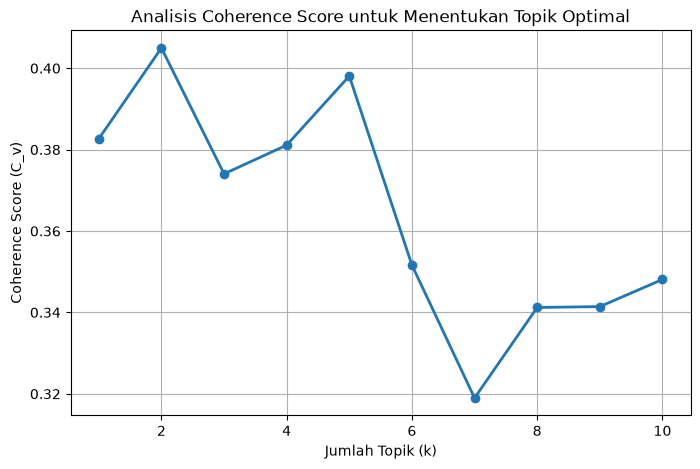

Jumlah Topik = 1 | Coherence Score = 0.3827
Jumlah Topik = 2 | Coherence Score = 0.4050
Jumlah Topik = 3 | Coherence Score = 0.3740
Jumlah Topik = 4 | Coherence Score = 0.3811
Jumlah Topik = 5 | Coherence Score = 0.3981
Jumlah Topik = 6 | Coherence Score = 0.3516
Jumlah Topik = 7 | Coherence Score = 0.3190
Jumlah Topik = 8 | Coherence Score = 0.3412
Jumlah Topik = 9 | Coherence Score = 0.3414
Jumlah Topik = 10 | Coherence Score = 0.3481


In [11]:
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

coherence_values = []
model_list = []
start_k = 1
limit_k = 10

for num_topics in range(start_k, limit_k + 1):
    model = models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)
    model_list.append(model)
    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v', processes=1)
    coherence_values.append(coherencemodel.get_coherence())

x = range(start_k, limit_k + 1)
plt.figure(figsize=(8, 5))
plt.plot(x, coherence_values, marker='o', color='#1f77b4', linewidth=2)
plt.xlabel("Jumlah Topik (k)")
plt.ylabel("Coherence Score (C_v)")
plt.title("Analisis Coherence Score untuk Menentukan Topik Optimal")
plt.grid(True)
plt.show()

for k_val, score in zip(x, coherence_values):
    print(f"Jumlah Topik = {k_val} | Coherence Score = {score:.4f}")


### Kesimpulan Penentuan Jumlah Topik
Berdasarkan hasil analisis **Coherence Score ($C_v$)** di atas:

- Nilai $C_v$ tertinggi menentukan jumlah topik optimal $k^*$ secara **objektif** dan **data-driven**.
- Perlu diperhatikan bahwa nilai $C_v$ yang terus meningkat seiring bertambahnya $k$ tidak selalu berarti topik lebih bermakna secara semantik — bisa terjadi **overfitting** atau topik yang terlalu granular.
- Oleh karena itu, kita memilih $k$ dengan **nilai $C_v$ tertinggi** sekaligus **logis secara interpretasi**, yakni:
  - Jika puncak berada di ujung (k=10), pertimbangkan puncak lokal sebelumnya.
  - Jika ada lonjakan signifikan di suatu titik, titik tersebut diprioritaskan.

Cell berikut secara otomatis memilih jumlah topik optimal dari hasil analisis di atas.


In [12]:
# Memilih jumlah topik optimal secara dinamis dari hasil analisis Coherence Score
optimal_k = start_k + coherence_values.index(max(coherence_values))
optimal_score = max(coherence_values)

print(f"Jumlah topik optimal yang dipilih: k = {optimal_k}")
print(f"Coherence Score (C_v): {optimal_score:.4f}")


Jumlah topik optimal yang dipilih: k = 2
Coherence Score (C_v): 0.4050


### 2. Pelatihan Model LDA Final dengan $k$ Optimal

Model LDA dilatih menggunakan jumlah topik yang telah ditentukan secara objektif dari analisis $C_v$ di atas.
Ini adalah tahap **Topic Detection** — yaitu proses menemukan tema-tema tersembunyi dari konten teks tweet.

> **Catatan penting**: Tahap ini murni beroperasi di level **teks/konten**, bukan di level jaringan/pengguna.
> Topic Detection menghasilkan distribusi topik per tweet, yang kemudian digunakan sebagai dasar membangun jaringan pengguna (SNA).


In [13]:
# num_topics diambil dari hasil analisis coherence score (dinamis)
num_topics = optimal_k

lda_model = models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)

print(f"LDA Model Topics (k={num_topics}):")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")


LDA Model Topics (k=2):
Topic 0: 0.033*"anggaran" + 0.025*"puluhan_ribu" + 0.016*"unit" + 0.012*"yasa_artha" + 0.012*"unit_didistribusikan" + 0.012*"parkir_gudang" + 0.012*"pernyataan_kepala" + 0.012*"tempo_melaporkan" + 0.012*"sorotan_ramai" + 0.012*"wilayah_bogor"
Topic 1: 0.051*"kaos_kaki" + 0.011*"proyek" + 0.011*"indonesia" + 0.011*"kepala" + 0.011*"sulit" + 0.011*"purbaya" + 0.010*"badan_gizi" + 0.010*"harga_pasar" + 0.010*"nasional_sorotan" + 0.010*"mobilitas_petugas"


### 2a. Interpretasi & Pelabelan Topik Hasil LDA

Setelah model LDA selesai dilatih, setiap topik direpresentasikan sebagai kumpulan kata dengan bobot tertinggi.
Kita perlu menginterpretasikan tiap topik secara **manual** untuk memberikan label yang bermakna.

> **Mengapa penting?** Topik LDA hanyalah distribusi kata — tanpa label, kita tidak bisa mengkomunikasikan
> temuan secara bermakna. Label ini juga digunakan untuk memvalidasi apakah komunitas yang terbentuk
> nantinya sudah sesuai dengan tema yang seharusnya.

Label di bawah ini ditetapkan berdasarkan kata-kata dominan pada masing-masing topik.
Sesuaikan label jika hasil run menghasilkan topik yang berbeda.


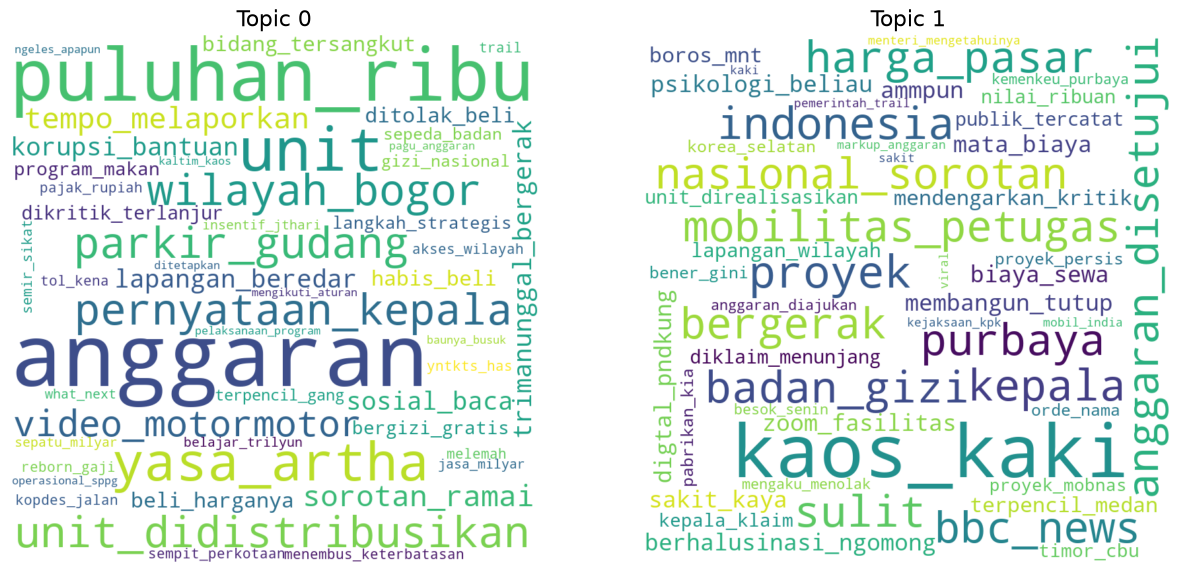

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, num_topics, figsize=(15, 7), sharex=True, sharey=True)
for i in range(num_topics):
    topic_words = dict(lda_model.show_topic(i, topn=50))
    wordcloud = WordCloud(width=800, height=800, background_color='white').fit_words(topic_words)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis("off")
    axes[i].set_title(f'Topic {i}', fontsize=16)
plt.show()

In [15]:
# Label topik -- HARUS disesuaikan secara manual dengan hasil run LDA saat ini.
# Format: {topic_id: 'Label Topik'}
# PENTING: update dictionary ini setiap kali k optimal berubah setelah run ulang.
TOPIC_LABELS = {
    0: 'Pengadaan Motor Listrik dan Transparansi Anggaran MBG',
    1: 'Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG',
}

TOPIC_LABELS_EN = {
    0: "Electric Motorcycle Procurement and Budget Transparency in the MBG Program",
    1: "Supporting Facility Procurement and Budget Efficiency in the MBG Program",
}

# Validasi: pastikan setiap topik hasil LDA punya label, agar tidak ada topik
# yang lolos tanpa label saat num_topics berubah (reproducibility safeguard).
missing_labels = [t for t in range(num_topics) if t not in TOPIC_LABELS]
if missing_labels:
    print(f"⚠️  PERINGATAN: topik {missing_labels} belum punya label di TOPIC_LABELS / "
          f"TOPIC_LABELS_EN. Update dictionary di atas sebelum melanjutkan analisis.")

print("=== LABEL TOPIK LDA ===")
print()
for idx, topic in lda_model.print_topics(-1, num_words=10):
    label = TOPIC_LABELS.get(idx, f'Topik {idx}')
    print(f"Topik {idx} -- [{label}]")
    print(f"  Kata kunci: {topic}")
    print()


=== LABEL TOPIK LDA ===

Topik 0 -- [Pengadaan Motor Listrik dan Transparansi Anggaran MBG]
  Kata kunci: 0.033*"anggaran" + 0.025*"puluhan_ribu" + 0.016*"unit" + 0.012*"yasa_artha" + 0.012*"unit_didistribusikan" + 0.012*"parkir_gudang" + 0.012*"pernyataan_kepala" + 0.012*"tempo_melaporkan" + 0.012*"sorotan_ramai" + 0.012*"wilayah_bogor"

Topik 1 -- [Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG]
  Kata kunci: 0.051*"kaos_kaki" + 0.011*"proyek" + 0.011*"indonesia" + 0.011*"kepala" + 0.011*"sulit" + 0.011*"purbaya" + 0.010*"badan_gizi" + 0.010*"harga_pasar" + 0.010*"nasional_sorotan" + 0.010*"mobilitas_petugas"



### Assigning Dominant Topic per Tweet


In [16]:
def get_dominant_topic(lda_model, corpus_item):
    topic_distribution = lda_model.get_document_topics(corpus_item, minimum_probability=0.0)
    dominant_topic = sorted(topic_distribution, key=lambda x: x[1], reverse=True)[0]
    return dominant_topic[0], dominant_topic[1]

df['dominant_topic_id'] = None
df['dominant_topic_probability'] = None

all_topic_distributions = []
for i, doc_bow in enumerate(corpus):
    topic_dist = lda_model.get_document_topics(doc_bow, minimum_probability=0.0)
    dominant_id, dominant_prob = get_dominant_topic(lda_model, doc_bow)
    df.loc[i, 'dominant_topic_id'] = dominant_id
    df.loc[i, 'dominant_topic_probability'] = dominant_prob

    for topic_id, prob in topic_dist:
        all_topic_distributions.append({'tweet_index': i, 'topic_id': topic_id, 'probability': prob})

df_tweet_topic_probs = pd.DataFrame(all_topic_distributions)
df_tweet_topic_probs = df_tweet_topic_probs.merge(
    df[['author']].reset_index().rename(columns={'index': 'tweet_index'}),
    on='tweet_index'
)

print("Tweets with dominant topics:")
display(df[['text', 'processed_text', 'dominant_topic_id', 'dominant_topic_probability']].head())


Tweets with dominant topics:


,text,processed_text,dominant_topic_id,dominant_topic_probability
0,"Guys, ada satu angka yang keluar dari riset te...",guys angka riset terbaru celios gue salah fakt...,0,0.996713
1,@tv_inn47694 @menuembegejelek Klo bukan buzzer...,klo buzzer kasih fakta kaum sakit hati ngeriti...,0,0.6732
2,"MBG itu proyek korupsi, memang di dunia lolos ...",proyek korupsi dunia lolos hukuman lihat kelak...,0,0.853179
3,@tempodotco Yg turun ke rakyat brp persen....k...,turun rakyat persenke vendor vendor brpmotor g...,0,0.850202
4,@SeputarTetangga Motor listrik MBG lah,,0,0.5


In [51]:
df[df['dominant_topic_id']==1][['text', 'processed_text', 'author', 'dominant_topic_id', 'dominant_topic_probability']]

,text,processed_text,author,dominant_topic_id,dominant_topic_probability
13,@OG_Whip @ryenyuku @svnwcloudie @iPopBase Prog...,program maksudmu proyek kaos kaki merk goib an...,Christark___,1,0.91653
16,@zalkad @Metro_TV Apa pengalihan isu motor lis...,pengalihan isu kaos kaki mobil india sonotan t...,Vikry72350632,1,0.928296
18,Pengadaan motor listrik oleh Badan Gizi Nasion...,badan gizi nasional sorotan publik tercatat un...,supremasisipil,1,0.949703
20,@zalkad @Metro_TV Apakah secara psikologi beli...,psikologi beliau sakit kaya berhalusinasi ngom...,Agustinus_Arif,1,0.961527
27,Pengadaan motor listrik utk proyek MBG persis ...,proyek persis proyek mobnas orde nama timor cb...,cnaipospos,1,0.92855
...,...,...,...,...,...
4038,MBG: Kepala BGN klaim nilai pengadaan ribuan m...,kepala klaim nilai ribuan harga pasar bbc news...,LabourTand90381,1,0.915315
4039,Hebat...hebat...\nKasus markup mbg anggaran pe...,markup anggaran kejaksaan kpk bergerak,PZoill94844,1,0.874956
4041,@LambeSahamjja dan proses pengadaan motor list...,proses dibuka blokir sepengetahuan purbaya,AgungYudanto,1,0.873609
4043,@jawafess keknya masnya pengangguran trs emosi...,keknya masnya pengangguran emosi liat perilaku...,kenekadit_,1,0.937482


### Distribusi Dominan Topic

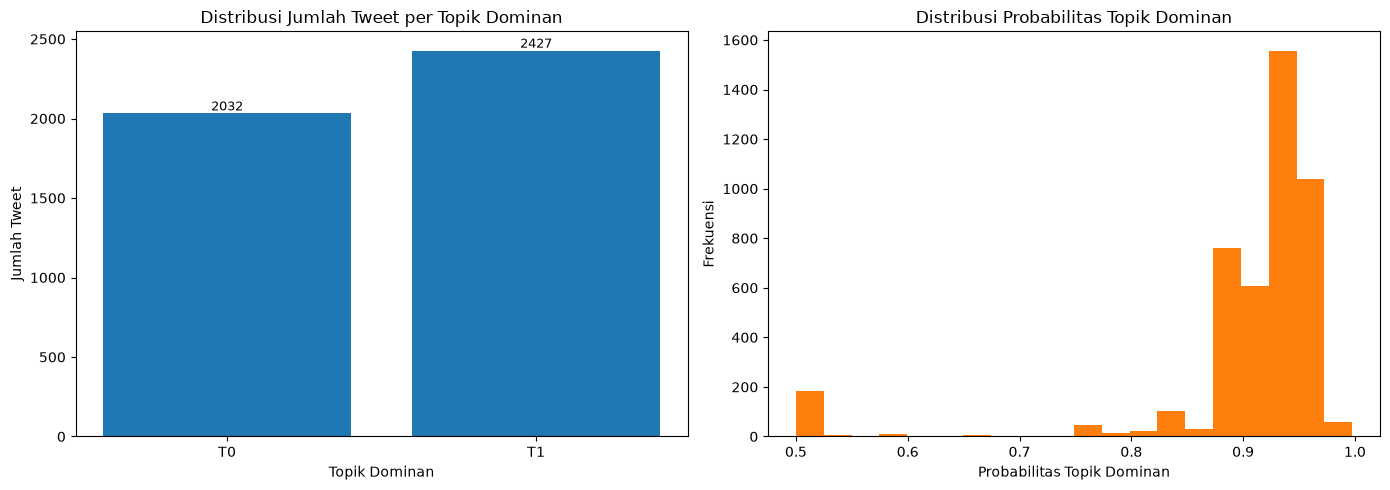

,topic_id,label,n_tweets,share_pct
0,0,Pengadaan Motor Listrik dan Transparansi Angga...,2032,45.57
1,1,Pengadaan Fasilitas Pendukung dan Efisiensi An...,2427,54.43


In [17]:
topic_counts = df['dominant_topic_id'].dropna().astype(int).value_counts().sort_index()
topic_labels_for_plot = [TOPIC_LABELS.get(t, f"Topik {t}") for t in topic_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: jumlah tweet per topik dominan
axes[0].bar(range(len(topic_counts)), topic_counts.values, color='#1f77b4')
axes[0].set_xticks(range(len(topic_counts)))
axes[0].set_xticklabels([f"T{t}" for t in topic_counts.index])
axes[0].set_xlabel("Topik Dominan")
axes[0].set_ylabel("Jumlah Tweet")
axes[0].set_title("Distribusi Jumlah Tweet per Topik Dominan")
for i, v in enumerate(topic_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

# Panel 2: distribusi probabilitas topik dominan (histogram)
axes[1].hist(df['dominant_topic_probability'].dropna().astype(float), bins=20, color='#ff7f0e')
axes[1].set_xlabel("Probabilitas Topik Dominan")
axes[1].set_ylabel("Frekuensi")
axes[1].set_title("Distribusi Probabilitas Topik Dominan")

plt.tight_layout()
# save_figure(fig, "dominant_topic_distribution.png")
plt.show()

dominant_topic_table = pd.DataFrame({
    "topic_id": topic_counts.index,
    "label": topic_labels_for_plot,
    "n_tweets": topic_counts.values,
    "share_pct": (100 * topic_counts.values / topic_counts.sum()).round(2),
})
display(dominant_topic_table)
# save_table(dominant_topic_table.set_index("topic_id"), "dominant_topic_distribution.csv")

### 2b. Validasi Kualitatif — Sampel Tweet per Topik

Untuk memverifikasi bahwa model LDA telah memetakan topik dengan benar,
kita tampilkan beberapa contoh tweet dari masing-masing topik dominan.

Ini adalah **validasi kualitatif**: apakah isi tweet memang sesuai dengan label topik yang kita berikan?


In [19]:
# Tampilkan 3 sampel tweet per topik untuk validasi kualitatif
# drop_duplicates per author agar tidak muncul tweet dari user yang sama berulang
N_SAMPLES = 3

print("=== SAMPEL TWEET PER TOPIK (Validasi Kualitatif) ===\n")
for topic_id in sorted(df['dominant_topic_id'].dropna().unique()):
    topic_id = int(topic_id)
    label = TOPIC_LABELS.get(topic_id, f'Topik {topic_id}')
    subset = df[df['dominant_topic_id'] == topic_id][['author', 'text', 'dominant_topic_probability']]
    subset = subset.drop_duplicates(subset='author')
    subset = subset.sort_values('dominant_topic_probability', ascending=False).head(N_SAMPLES)

    print(f"{'='*70}")
    print(f"Topik {topic_id} — {label}")
    print(f"{'='*70}")
    for _, row in subset.iterrows():
        prob = row['dominant_topic_probability']
        author = row['author']
        text_preview = row['text'][:200].replace('\n', ' ')
        print(f"  [@{author}] (prob={prob:.3f})")
        print(f'  "{text_preview}..."')
        print()


=== SAMPEL TWEET PER TOPIK (Validasi Kualitatif) ===

Topik 0 — Pengadaan Motor Listrik dan Transparansi Anggaran MBG
  [@LambeSahamjja] (prob=0.997)
  "Guys, ada satu angka yang keluar dari riset terbaru Celios yang menurut gue adalah salah satu fakta paling mengejutkan tentang Indonesia yang perlu lo dengar hari ini.  50 orang paling kaya di Indones..."

  [@deliknewsX] (prob=0.996)
  "MBG Serap Rp60 Triliun di 27.000 SPPG, Pengawasan BPOM Hanya Rp2,9 Miliar (0,0048%) – Risiko Sistemik yang Mengancam  Program Makan Bergizi Gratis (MBG) adalah program strategis nasional untuk interve..."

  [@RadioElshinta] (prob=0.996)
  "DPR Minta Batalkan Pengadaan 20 Ribu Motor Listrik oleh BGN, Komisi IX: Tidak Tepat Sasaran  JAKARTA  — Wakil Ketua Komisi IX DPR RI Charles Honoris mengkritik rencana pengadaan puluhan ribu motor lis..."

Topik 1 — Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG
  [@Agustinus_Arif] (prob=0.962)
  "@zalkad @Metro_TV Apakah secara psikologi beliau sakit ya? 

### 3. Perbedaan Topic Detection dan Community Detection

Dua konsep ini sering tertukar, namun memiliki peran yang sangat berbeda dalam pipeline analisis ini:

| Aspek | **Topic Detection** | **Community Detection** |
|---|---|---|
| **Apa yang dianalisis** | Konten teks (tweet) | Struktur jaringan antar user |
| **Metode** | LDA (Latent Dirichlet Allocation) | Louvain, Greedy Modularity, LPA |
| **Unit analisis** | Dokumen / tweet | Node / pengguna (user) |
| **Output** | Distribusi topik per tweet | Kelompok (komunitas) user |
| **Kapan dilakukan** | **Sebelum** graf dibangun | **Setelah** graf dibangun |
| **Domain ilmu** | NLP / Text Mining | Social Network Analysis (SNA) |

**Alur dalam penelitian ini:**
1. 📄 **Topic Detection (LDA)** → Setiap tweet dipetakan ke distribusi topik
2. 👤 **User-Topic Matrix** → Profil topik setiap pengguna dibangun dari rata-rata distribusi topik tweet mereka
3. 🕸️ **Graf Kesamaan** → Dua user dihubungkan jika cosine similarity profil topik mereka ≥ threshold
4. 🎨 **Community Detection** → Graf diwarnai/dikelompokkan berdasarkan algoritma deteksi komunitas

> Simpelnya: **Topic Detection** menjawab *"Tentang apa tweet ini?"*, sedangkan **Community Detection** menjawab *"Siapa user yang punya ketertarikan serupa?"*


### Membuat Matriks Distribusi Topik Pengguna (User-Topic Matrix)
Mengagregasikan distribusi topik setiap pengguna dari semua tweet mereka menggunakan fungsi rata-rata `.mean()`.


In [20]:
user_topic_agg = df_tweet_topic_probs.groupby(['author', 'topic_id'])['probability'].mean().reset_index()
user_topic_matrix = user_topic_agg.pivot(index='author', columns='topic_id', values='probability').fillna(0)

print("User-Topic Distribution Matrix (head):")
display(user_topic_matrix.head())


User-Topic Distribution Matrix (head):


topic_id,0,1
author,,
0___0cat,0.874432,0.125568
0ceanbloom,0.888528,0.111472
3siji3,0.876817,0.123183
AbdullahYu76015,0.889215,0.110785
AgungYudanto,0.126391,0.873609


### Membangun Graf Kesamaan Topik Antar Pengguna


In [21]:
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

# Simpan user_topic_matrix tanpa kolom entropy (jika ada)
topic_cols = [col for col in user_topic_matrix.columns if col != 'entropy']
user_topic_clean = user_topic_matrix[topic_cols]

user_similarity_matrix = cosine_similarity(user_topic_clean)
user_similarity_df = pd.DataFrame(user_similarity_matrix, index=user_topic_clean.index, columns=user_topic_clean.index)

G_topic = nx.Graph()
G_topic.add_nodes_from(user_similarity_df.index)

similarity_threshold = 0.8
for i in range(len(user_similarity_df.index)):
    for j in range(i + 1, len(user_similarity_df.index)):
        user1 = user_similarity_df.index[i]
        user2 = user_similarity_df.index[j]
        similarity = user_similarity_df.loc[user1, user2]
        if similarity > similarity_threshold:
            G_topic.add_edge(user1, user2, weight=similarity)

# Hapus node terisolasi
isolated_nodes = list(nx.isolates(G_topic))
G_topic.remove_nodes_from(isolated_nodes)

print(f"Jaringan terbentuk dengan {G_topic.number_of_nodes()} node dan {G_topic.number_of_edges()} edge.")


Jaringan terbentuk dengan 397 node dan 49836 edge.


### Visualisasi Graf Kesamaan Topik Antar Pengguna

Graf di bawah ini menampilkan jaringan pengguna sebelum dilakukan community detection.
Setiap **node** adalah satu user, dan **edge** menghubungkan dua user yang memiliki
cosine similarity distribusi topik ≥ 0.8. Node yang lebih besar memiliki lebih banyak koneksi (degree tinggi).
Warna node merepresentasikan topik dominan masing-masing user.


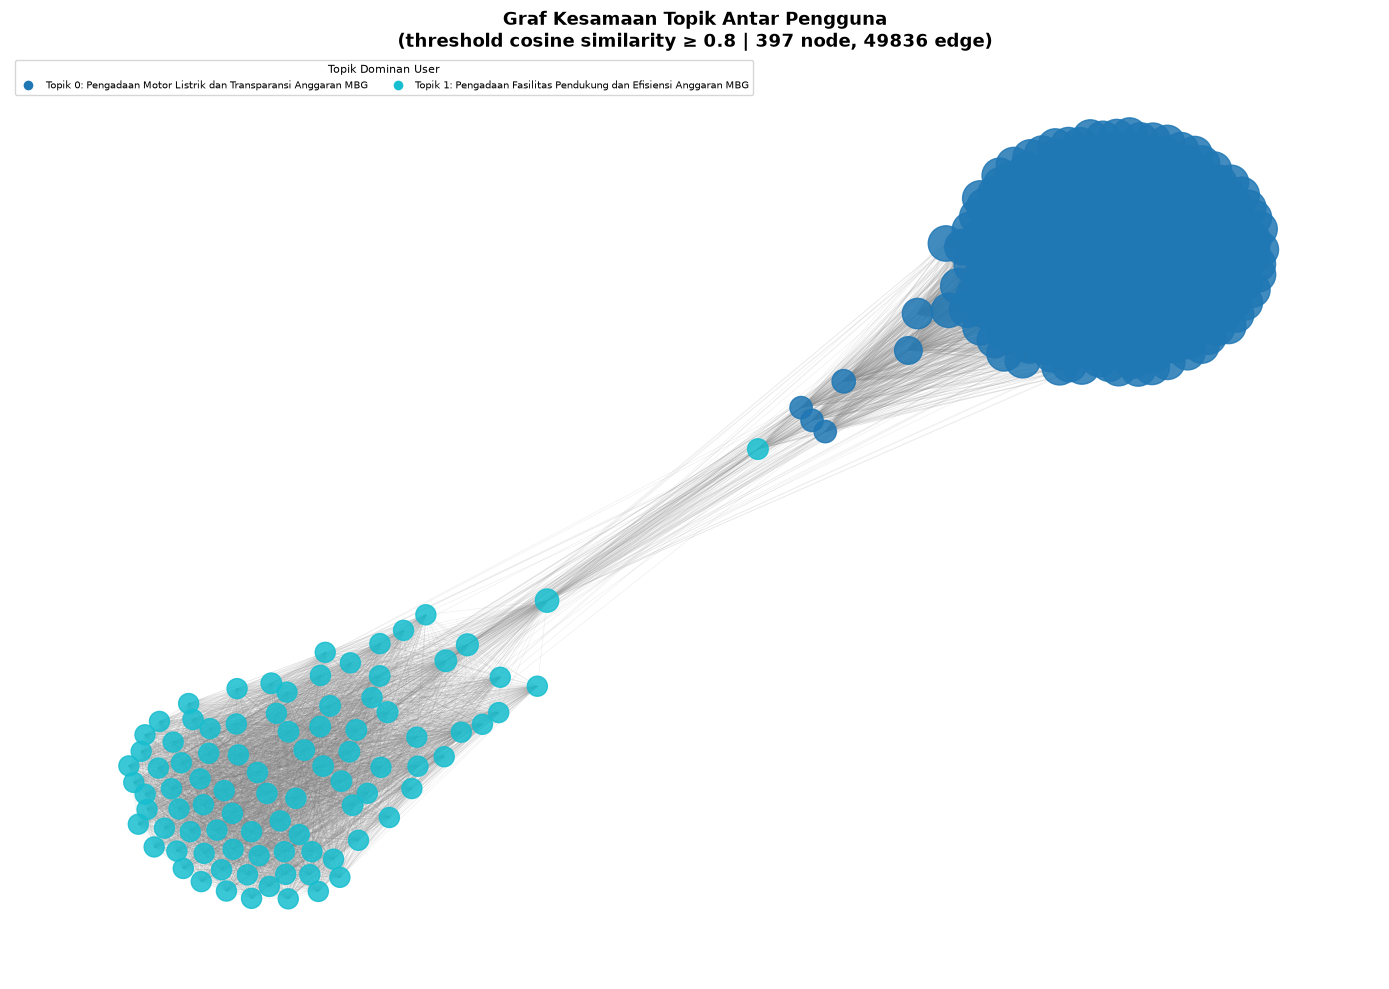

Gambar disimpan sebagai Topic_Similarity_Graph.png


In [22]:
import matplotlib
# Visualisasi Graf Kesamaan Topik (sebelum community detection)
fig, ax = plt.subplots(figsize=(14, 10))

# Layout
pos = nx.spring_layout(G_topic, seed=42, k=0.4)

# Warna node berdasarkan topik dominan user
# Bangun mapping author -> dominant_topic_id dari df
author_topic_map = df.dropna(subset=['author', 'dominant_topic_id']) \
    .groupby('author')['dominant_topic_id'] \
    .agg(lambda x: x.mode()[0]) \
    .astype(int).to_dict()

n_topics = num_topics
cmap_topic = matplotlib.colormaps.get_cmap('tab10').resampled(n_topics)

node_colors = []
node_sizes = []
for node in G_topic.nodes():
    tid = author_topic_map.get(node, 0)
    node_colors.append(cmap_topic(tid % n_topics))
    node_sizes.append(30 + G_topic.degree(node) * 2)  # ukuran proporsional degree

# Draw
nx.draw_networkx_edges(G_topic, pos, alpha=0.15, width=0.4, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G_topic, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)

# Legend topik
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap_topic(tid % n_topics), markersize=8,
           label=f'Topik {tid}: {TOPIC_LABELS.get(tid, "")}')
    for tid in range(n_topics)
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=7,
          title='Topik Dominan User', title_fontsize=8,
          framealpha=0.8, ncol=2)

ax.set_title(
    f"Graf Kesamaan Topik Antar Pengguna\n"
    f"(threshold cosine similarity ≥ 0.8 | {G_topic.number_of_nodes()} node, {G_topic.number_of_edges()} edge)",
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig("Topic_Similarity_Graph.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan sebagai Topic_Similarity_Graph.png")


### 4. Perbandingan Algoritma Community Detection

Untuk mendeteksi komunitas pengguna secara robust, kita membandingkan **3 algoritma** dengan karakteristik berbeda:

| Algoritma | Pendekatan | Kelebihan | Kekurangan |
|---|---|---|---|
| **Louvain** | Heuristik hierarkis, memaksimalkan modularity secara lokal | Sangat cepat, skalabel untuk graf besar, hasil modularity tinggi | Non-deterministik (ada variasi antar run) |
| **Greedy Modularity (CNM)** | Agglomerative — gabung komunitas yang hasilkan peningkatan modularity terbesar | Deterministik, mudah diinterpretasi | Lebih lambat pada graf besar, cenderung temukan komunitas besar |
| **Label Propagation (LPA)** | Propagasi label secara dinamis sepanjang edge | Sangat cepat, tanpa parameter | Non-deterministik, hasil bisa tidak stabil |

**Alasan pemilihan ketiga algoritma ini:**
- Mewakili 3 paradigma berbeda: *optimasi lokal (Louvain)*, *penggabungan greedy (CNM)*, dan *propagasi label (LPA)*
- Memungkinkan validasi silang: jika ketiga algoritma menghasilkan struktur komunitas serupa, hasilnya lebih dapat dipercaya
- Modularity digunakan sebagai metrik pembanding objektif (semakin tinggi = komunitas semakin terpisah dengan baik)


In [23]:
import networkx.algorithms.community as nx_comm

# 1. Louvain Algorithm
comm_louvain = nx_comm.louvain_communities(G_topic, weight='weight', seed=42)
mod_louvain = nx_comm.modularity(G_topic, comm_louvain, weight='weight')

# 2. Greedy Modularity Algorithm (Clauset-Newman-Moore)
comm_greedy = list(nx_comm.greedy_modularity_communities(G_topic, weight='weight'))
mod_greedy = nx_comm.modularity(G_topic, comm_greedy, weight='weight')

# 3. Label Propagation Algorithm (LPA)
comm_lpa = list(nx_comm.label_propagation_communities(G_topic))
mod_lpa = nx_comm.modularity(G_topic, comm_lpa, weight='weight')

print("===== PERBANDINGAN ALGORITMA KOMUNITAS =====")
print(f"Louvain           -> Jumlah Komunitas: {len(comm_louvain)} | Modularity: {mod_louvain:.4f}")
print(f"Greedy Modularity -> Jumlah Komunitas: {len(comm_greedy)} | Modularity: {mod_greedy:.4f}")
print(f"Label Propagation -> Jumlah Komunitas: {len(comm_lpa)} | Modularity: {mod_lpa:.4f}")

# Simpan mapping node -> community untuk tiap algoritma
louvain_map = {node: i for i, comm in enumerate(comm_louvain) for node in comm}
greedy_map = {node: i for i, comm in enumerate(comm_greedy) for node in comm}
lpa_map = {node: i for i, comm in enumerate(comm_lpa) for node in comm}


===== PERBANDINGAN ALGORITMA KOMUNITAS =====
Louvain           -> Jumlah Komunitas: 2 | Modularity: 0.1502
Greedy Modularity -> Jumlah Komunitas: 2 | Modularity: 0.1502
Label Propagation -> Jumlah Komunitas: 2 | Modularity: 0.1489


### Visualisasi Perbandingan Komunitas — 3 Algoritma

Setiap warna merepresentasikan satu komunitas yang terdeteksi oleh masing-masing algoritma.


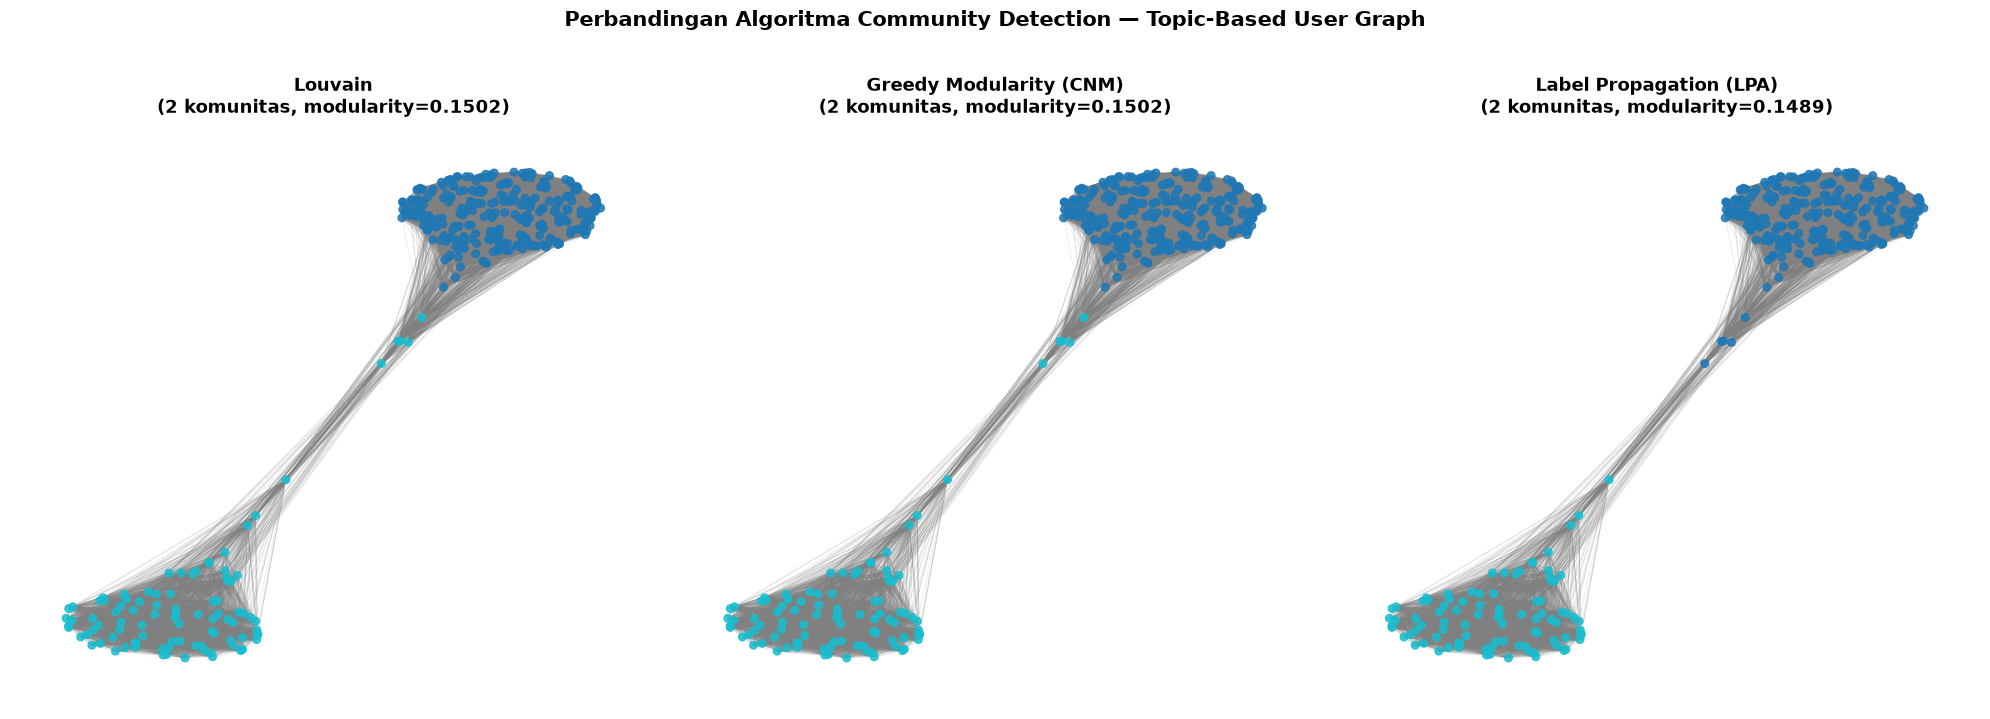

Gambar disimpan sebagai Topic_Communities_Comparison.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib

# Layout posisi node (sama untuk ketiga visualisasi agar mudah dibandingkan)
pos = nx.spring_layout(G_topic, seed=42)

def draw_community_graph(G, community_map, title, ax):
    communities = sorted(set(community_map.values()))
    cmap = matplotlib.colormaps.get_cmap('tab10').resampled(len(communities))
    node_colors = [cmap(community_map[node]) for node in G.nodes()]
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5, edge_color='gray', ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=30, alpha=0.85, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

draw_community_graph(G_topic, louvain_map,
    f"Louvain\n({len(comm_louvain)} komunitas, modularity={mod_louvain:.4f})", axes[0])
draw_community_graph(G_topic, greedy_map,
    f"Greedy Modularity (CNM)\n({len(comm_greedy)} komunitas, modularity={mod_greedy:.4f})", axes[1])
draw_community_graph(G_topic, lpa_map,
    f"Label Propagation (LPA)\n({len(comm_lpa)} komunitas, modularity={mod_lpa:.4f})", axes[2])

plt.suptitle("Perbandingan Algoritma Community Detection — Topic-Based User Graph", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("Topic_Communities_Comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan sebagai Topic_Communities_Comparison.png")


### Kesimpulan Perbandingan Algoritma Community Detection

Berdasarkan hasil di atas, kita dapat menarik beberapa kesimpulan:

- **Modularity** digunakan sebagai metrik objektif. Semakin tinggi nilai modularity (mendekati 1.0), semakin baik pemisahan antar komunitas.
- Algoritma dengan modularity tertinggi dipilih sebagai **algoritma utama** untuk analisis lanjutan.
- Perbedaan jumlah komunitas antar algoritma menunjukkan **sensitivitas masing-masing metode** terhadap struktur lokal vs global jaringan.

> Perbandingan ini penting agar hasil community detection **tidak bergantung pada satu algoritma saja** (menghindari bias metodologis).


### 5. Deteksi User yang Overlap Komunitas (Bridge Users)

**Apa itu user yang "overlap"?**

Dalam jaringan komunitas, *overlap* terjadi ketika seorang user memiliki distribusi ketertarikan topik yang **tersebar merata ke banyak topik**, bukan terkonsentrasi pada satu topik dominan. User seperti ini berperan sebagai **jembatan (bridge)** antar komunitas — mereka bisa relevan di banyak kelompok sekaligus.

**Metode deteksi:**  
Kita menggunakan **Shannon Entropy** dari profil distribusi topik setiap user:
- Entropy **tinggi** → distribusi merata → user berpotensi overlap banyak komunitas
- Entropy **rendah** → distribusi terpusat → user dominan di satu topik/komunitas

> Ini menjawab pertanyaan: *"Apakah ada user yang bisa masuk ke lebih dari satu komunitas?"* — Jawabannya: ya, mereka adalah user dengan entropy tinggi.


In [25]:
import scipy.stats

# Hitung entropy distribusi topik per user (tanpa kolom entropy sebelumnya)
topic_cols_only = [col for col in user_topic_matrix.columns if col != 'entropy']
user_topic_for_entropy = user_topic_matrix[topic_cols_only].copy()

user_topic_for_entropy['entropy'] = user_topic_for_entropy.apply(
    lambda row: scipy.stats.entropy(row + 1e-10),  # +eps untuk menghindari log(0)
    axis=1
)

# Simpan kembali ke user_topic_matrix
user_topic_matrix['entropy'] = user_topic_for_entropy['entropy']

top_overlap = user_topic_matrix.sort_values(by='entropy', ascending=False)[['entropy']].head(10)
print("10 User Paling Overlap (Bridge Users — tersebar di banyak topik):")
display(top_overlap)

# Ambil threshold: user dengan entropy > mean + 1 std dianggap overlap
entropy_mean = user_topic_matrix['entropy'].mean()
entropy_std = user_topic_matrix['entropy'].std()
threshold_entropy = entropy_mean + entropy_std

bridge_users = user_topic_matrix[user_topic_matrix['entropy'] > threshold_entropy].index.tolist()
print(f"\nJumlah Bridge Users (entropy > {threshold_entropy:.4f}): {len(bridge_users)}")


10 User Paling Overlap (Bridge Users — tersebar di banyak topik):


topic_id,entropy
author,
normansihite,0.693147
Ombahku,0.693147
Argadhahana,0.693147
beulangong174,0.692988
TirtoID,0.692850
Kastam67,0.690440
ainanoteu,0.688847
ddycw,0.686285
LangkahSantai,0.682037



Jumlah Bridge Users (entropy > 0.4577): 62


### Visualisasi Bridge Users pada Jaringan


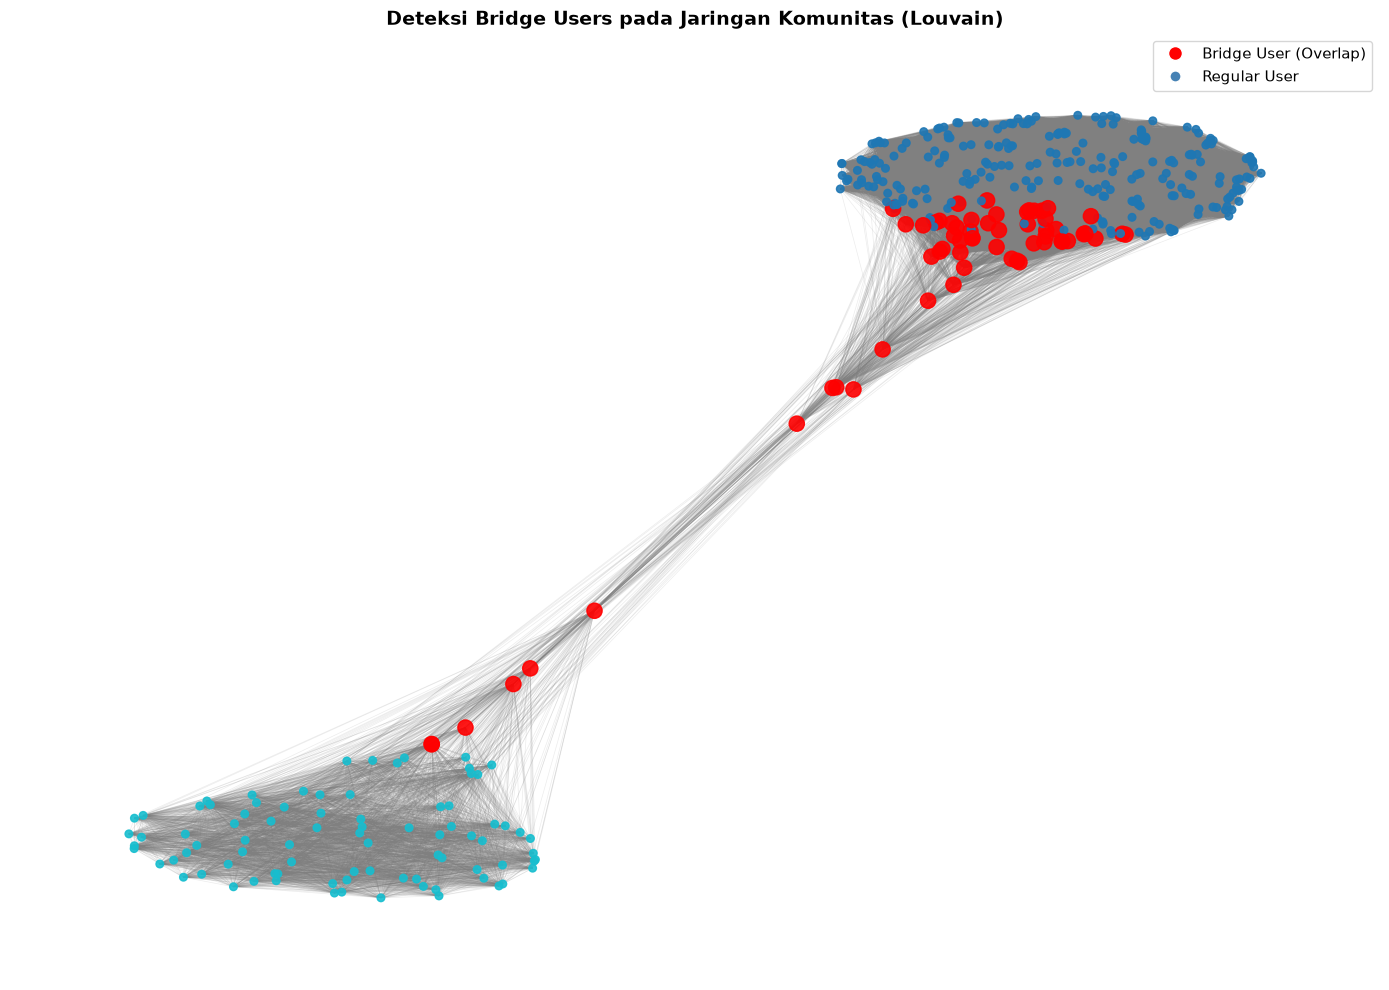

Gambar disimpan sebagai Topic_Communities_BridgeUsers.png


In [26]:
import matplotlib
# Visualisasi graf Louvain dengan Bridge Users ditandai khusus
fig, ax = plt.subplots(figsize=(14, 10))

# Warna node berdasarkan komunitas Louvain
communities = sorted(set(louvain_map.values()))
cmap = matplotlib.colormaps.get_cmap('tab10').resampled(len(communities))
node_colors = []
node_sizes = []

for node in G_topic.nodes():
    if node in bridge_users and node in louvain_map:
        node_colors.append('red')        # Bridge user ditandai merah
        node_sizes.append(120)
    elif node in louvain_map:
        node_colors.append(cmap(louvain_map[node]))
        node_sizes.append(30)
    else:
        node_colors.append('gray')
        node_sizes.append(20)

nx.draw_networkx_edges(G_topic, pos, alpha=0.15, width=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G_topic, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Bridge User (Overlap)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Regular User'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
ax.set_title("Deteksi Bridge Users pada Jaringan Komunitas (Louvain)", fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig("Topic_Communities_BridgeUsers.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gambar disimpan sebagai Topic_Communities_BridgeUsers.png")


### 6. Validasi Kualitatif — Sampel Tweet per Komunitas

Setelah komunitas terdeteksi, kita ambil sampel tweet dari user di tiap komunitas
untuk memverifikasi apakah **pengelompokan komunitas sudah sesuai** dengan topik yang dominan.

Ini menjawab pertanyaan: *"Apakah user dalam satu komunitas memang membicarakan hal yang sama?"*

Kita menggunakan hasil **algoritma Louvain** (modularity tertinggi) sebagai dasar validasi.


In [27]:
# Mapping author -> community (Louvain)
df_community = pd.DataFrame([
    {'author': node, 'community_id': louvain_map[node]}
    for node in G_topic.nodes()
])

# Gabungkan dengan dataframe tweet
df_with_comm = df.merge(df_community, on='author', how='inner')
df_with_comm['dominant_topic_id'] = df_with_comm['dominant_topic_id'].astype('Int64')

N_COMM_SAMPLES = 3  # jumlah tweet sampel per komunitas

print("=== SAMPEL TWEET PER KOMUNITAS (Validasi Kualitatif) ===")
print("Algoritma: Louvain Community Detection\n")

for comm_id in sorted(df_with_comm['community_id'].unique()):
    comm_members = df_with_comm[df_with_comm['community_id'] == comm_id]

    # Topik dominan di komunitas ini
    top_topic = comm_members['dominant_topic_id'].mode()
    top_topic_id = int(top_topic.iloc[0]) if len(top_topic) > 0 else -1
    top_topic_label = TOPIC_LABELS.get(top_topic_id, '?')
    n_users = comm_members['author'].nunique()

    print(f"{'='*70}")
    print(f"Komunitas {comm_id} | {n_users} user | Topik Dominan: Topik {top_topic_id} — {top_topic_label}")
    print(f"{'='*70}")

    # Distribusi topik dalam komunitas
    topic_dist = comm_members['dominant_topic_id'].value_counts().head(3)
    for tid, cnt in topic_dist.items():
        lbl = TOPIC_LABELS.get(int(tid), '?')
        print(f"  Topik {tid} ({lbl}): {cnt} tweet")
    print()

    # Sampel tweet
    samples = comm_members[['author','text','dominant_topic_id']].drop_duplicates(subset='author').head(N_COMM_SAMPLES)
    for _, row in samples.iterrows():
        tid = int(row['dominant_topic_id']) if pd.notna(row['dominant_topic_id']) else -1
        lbl = TOPIC_LABELS.get(tid, '?')
        text_preview = str(row['text'])[:180].replace('\n', ' ')
        print(f"  [@{row['author']}] Topik {tid} — {lbl}")
        print(f'  "{text_preview}..."')
        print()


=== SAMPEL TWEET PER KOMUNITAS (Validasi Kualitatif) ===
Algoritma: Louvain Community Detection

Komunitas 0 | 302 user | Topik Dominan: Topik 0 — Pengadaan Motor Listrik dan Transparansi Anggaran MBG
  Topik 0 (Pengadaan Motor Listrik dan Transparansi Anggaran MBG): 1885 tweet

  [@LambeSahamjja] Topik 0 — Pengadaan Motor Listrik dan Transparansi Anggaran MBG
  "Guys, ada satu angka yang keluar dari riset terbaru Celios yang menurut gue adalah salah satu fakta paling mengejutkan tentang Indonesia yang perlu lo dengar hari ini.  50 orang pa..."

  [@wancuy19] Topik 0 — Pengadaan Motor Listrik dan Transparansi Anggaran MBG
  "@tv_inn47694 @menuembegejelek Klo bukan buzzer apa dong? Ada yg kasih fakta malah disebut kaum sakit hati ada yang ngeritik gak terima ya fakta lah. Coba jelaskan motor listrik, ka..."

  [@xineibn] Topik 0 — Pengadaan Motor Listrik dan Transparansi Anggaran MBG
  "MBG itu proyek korupsi, memang di dunia lolos hukuman, tapi lihat saja kelak hasilnya, ini jelas kok 